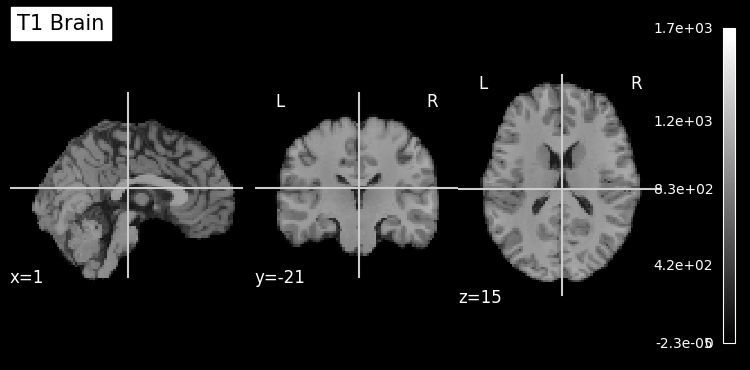

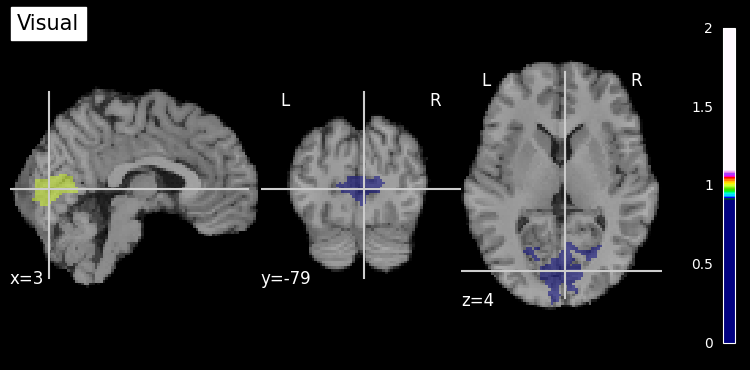

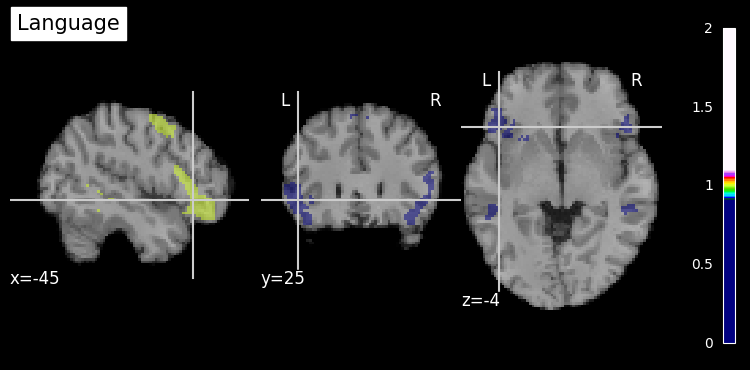

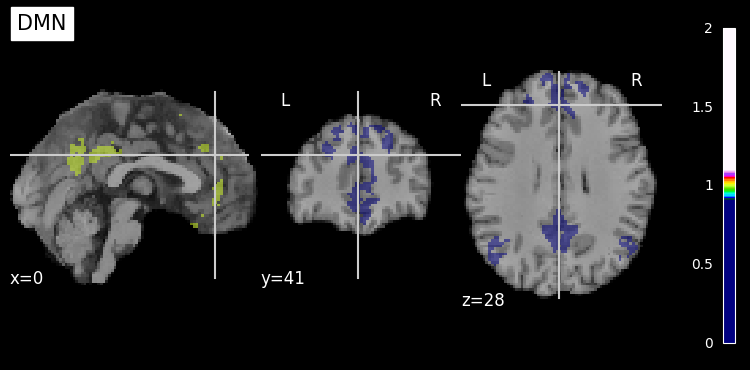

In [ ]:
import nibabel as nib
import numpy as np
from nilearn import plotting
from nilearn.image import new_img_like



base_path = "/mnt/c/Users/sadas/Downloads/"

t1_img = nib.load(base_path + "t1w.nii")

visual_mask = nib.load(base_path + "primary_visual.nii")
language_mask = nib.load(base_path + "language_sensaas.nii")
dmn_mask = nib.load(base_path + "dmn.nii")



plotting.plot_anat(t1_img, title="T1 Brain")



def safe_plot_roi(mask, bg, title, threshold=1e-6):
    data = mask.get_fdata()

   
    if np.count_nonzero(data) == 0:
        print(f"{title}: EMPTY MASK (skipped)")
        return

   
    binary_data = (data > threshold).astype(np.int32)
    binary_mask = new_img_like(mask, binary_data)

    
    plotting.plot_roi(
        binary_mask,
        bg_img=bg,
        alpha=0.5,
        title=title
    )



safe_plot_roi(visual_mask, t1_img, "Visual")
safe_plot_roi(language_mask, t1_img, "Language")
safe_plot_roi(dmn_mask, t1_img, "DMN")

plotting.show()